# Manipulación, limpieza y visualización de datos

**Unidad 4.b del temario** · Acompaña a `Clase_04_DatosPanel` · Notas: cap. 5

Este cuaderno recorre el camino completo **del archivo crudo al cuadro y la figura que se
entregan**, usando el panel de salarios de la NLSY. No es un catálogo de funciones de
`pandas`: es el flujo de trabajo real, con las decisiones que hay que tomar en el camino
y que casi nunca aparecen en el resultado final.

> **La tesis.** Las decisiones de limpieza y de presentación **son decisiones
> econométricas**, no cosméticas. Cómo se define la muestra, qué se hace con los
> faltantes, qué escala lleva un eje y qué se pone al lado de qué: todo eso cambia lo que
> el lector concluye. Un asistente de IA las toma por omisión y no las declara.

In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# Paleta del curso, validada para daltonismo (ver Notas de Clase).
AZUL, NARANJA, VIOLETA = "#2a78d6", "#eb6834", "#4a3aa7"
TINTA, TINTA2, GRIS = "#1a1a1a", "#4a4a4a", "#9a9a9a"

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "figure.dpi": 110,
})

panel = pd.read_csv("../../Clase_04_DatosPanel/wage_panel.csv")
print(f"{len(panel)} observaciones, {len(panel.columns)} columnas")
panel.head()

4360 observaciones, 12 columnas


,nr,year,black,exper,hisp,hours,married,educ,union,lwage,expersq,occupation
0,13,1980,0,1,0,2672,0,14,0,1.197540,1,9
1,13,1981,0,2,0,2320,0,14,1,1.853060,4,9
2,13,1982,0,3,0,2940,0,14,0,1.344462,9,9
3,13,1983,0,4,0,2960,0,14,0,1.433213,16,9
4,13,1984,0,5,0,3071,0,14,0,1.568125,25,5


## 1. Conocer los datos antes de tocarlos

El primer paso no es limpiar: es **mirar**. Casi todos los errores de la unidad 4 vienen
de suponer la estructura en vez de comprobarla.

In [2]:
print("Tipos y faltantes")
print("-" * 46)
diagnostico = pd.DataFrame({
    "tipo": panel.dtypes.astype(str),
    "faltantes": panel.isna().sum(),
    "distintos": panel.nunique(),
})
print(diagnostico.to_string())

Tipos y faltantes
----------------------------------------------
               tipo  faltantes  distintos
nr            int64          0        545
year          int64          0          8
black         int64          0          2
exper         int64          0         19
hisp          int64          0          2
hours         int64          0       1276
married       int64          0          2
educ          int64          0         13
union         int64          0          2
lwage       float64          0       3631
expersq       int64          0         19
occupation    int64          0          9


In [3]:
# ¿Es un panel balanceado? No se supone: se comprueba.
por_individuo = panel.groupby("nr").size()

print(f"Individuos          : {panel['nr'].nunique()}")
print(f"Años                : {panel['year'].min()}-{panel['year'].max()}")
print(f"Observaciones por nr: {por_individuo.unique()}")
print()
print("Balanceado" if por_individuo.nunique() == 1 else "NO balanceado")
print()
# Duplicados: un panel bien formado tiene una sola fila por (individuo, año).
duplicados = panel.duplicated(subset=["nr", "year"]).sum()
print(f"Filas duplicadas (nr, year): {duplicados}")

Individuos          : 545
Años                : 1980-1987
Observaciones por nr: [8]

Balanceado

Filas duplicadas (nr, year): 0


Panel balanceado, sin faltantes, sin duplicados. Es un archivo ya depurado y conviene
saberlo: **la mayoría de los datos reales no llegan así**, y el trabajo de esta sección
suele ser mucho más largo.

## 2. Variables derivadas y el problema de la escala

`lwage` está en logaritmos. Para presentar resultados en unidades que un lector entienda
hay que volver a niveles, y ahí aparece la primera decisión con consecuencias.

In [4]:
panel["wage"] = np.exp(panel["lwage"])

print("Salario por hora reconstruido:")
print(panel["wage"].describe().round(3).to_string())
print()
print(f"media de exp(lwage)  : {panel['wage'].mean():.3f}")
print(f"exp(media de lwage)  : {np.exp(panel['lwage'].mean()):.3f}")
print()
print("No son lo mismo, y la diferencia no es de redondeo: por la desigualdad")
print("de Jensen, E[exp(x)] >= exp(E[x]). La primera es la media aritmética del")
print("salario; la segunda es su media geométrica. Hay que decir cuál se reporta.")

Salario por hora reconstruido:
count    4360.000
mean        5.919
std         3.202
min         0.028
25%         3.860
50%         5.318
75%         7.323
max        57.504

media de exp(lwage)  : 5.919
exp(media de lwage)  : 5.203

No son lo mismo, y la diferencia no es de redondeo: por la desigualdad
de Jensen, E[exp(x)] >= exp(E[x]). La primera es la media aritmética del
salario; la segunda es su media geométrica. Hay que decir cuál se reporta.


## 3. Reestructurar: de largo a ancho y de vuelta

El formato **largo** (una fila por individuo-periodo) es el que quieren los estimadores de
panel. El **ancho** (una fila por individuo) sirve para calcular cambios y para ciertas
gráficas. Saber pasar de uno a otro sin perder observaciones es la habilidad central de
`pandas` en este curso.

In [5]:
ancho = panel.pivot(index="nr", columns="year", values="lwage")
print(f"Formato ancho: {ancho.shape[0]} individuos x {ancho.shape[1]} años")

# El crecimiento salarial de cada individuo entre el primer y el último año.
ancho["crecimiento"] = ancho[1987] - ancho[1980]

print(f"\nCrecimiento del log-salario 1980-1987:")
print(ancho["crecimiento"].describe().round(3).to_string())

# Y de regreso a formato largo, comprobando que no se perdió nada.
de_vuelta = ancho.drop(columns="crecimiento").stack().rename("lwage").reset_index()
print(f"\nDe vuelta a largo: {len(de_vuelta)} filas (originales: {len(panel)})", end="  ")
print("COINCIDE" if len(de_vuelta) == len(panel) else "SE PERDIERON FILAS")

Formato ancho: 545 individuos x 8 años

Crecimiento del log-salario 1980-1987:
count    545.000
mean       0.473
std        0.606
min       -0.970
25%        0.099
50%        0.390
75%        0.747
max        3.832

De vuelta a largo: 4360 filas (originales: 4360)  COINCIDE


## 4. Agregar: la operación donde más se equivoca uno

`groupby` es la herramienta más usada y la que produce los errores más silenciosos —el
[BUG 04](../02_Depurar/Bug_04_Panel_Desalineado.ipynb) es exactamente eso—. La distinción
que hay que tener clara:

| Método | Devuelve | Para qué |
|---|---|---|
| `.mean()` | una fila **por grupo** | resúmenes, cuadros |
| `.transform('mean')` | una fila **por observación** | crear variables, centrar |
| `.agg({...})` | varias columnas por grupo | cuadros con varias medidas |

In [6]:
# a) Resumen por grupo: una fila por año.
por_anio = panel.groupby("year").agg(
    salario_medio=("wage", "mean"),
    log_salario=("lwage", "mean"),
    tasa_sindical=("union", "mean"),
    n=("nr", "size"),
)
print(por_anio.round(4).to_string())

      salario_medio  log_salario  tasa_sindical    n
year                                                
1980         4.5872       1.3935         0.2514  545
1981         5.1223       1.5129         0.2495  545
1982         5.4067       1.5717         0.2569  545
1983         5.6400       1.6193         0.2459  545
1984         6.1025       1.6903         0.2514  545
1985         6.4712       1.7394         0.2239  545
1986         6.8196       1.7997         0.2110  545
1987         7.2038       1.8665         0.2624  545


In [7]:
# b) transform: una fila por observación, para construir variables.
panel["lwage_centrado"] = panel["lwage"] - panel.groupby("nr")["lwage"].transform("mean")

print(f"Filas tras centrar: {len(panel)}  (deben ser {len(panel)})")
print(f"Media dentro de cada individuo: "
      f"{panel.groupby('nr')['lwage_centrado'].mean().abs().max():.2e}")
print("\nCero hasta precisión de punto flotante: la transformación está bien.")

Filas tras centrar: 4360  (deben ser 4360)
Media dentro de cada individuo: 2.78e-16

Cero hasta precisión de punto flotante: la transformación está bien.


## 5. Del modelo al cuadro que se entrega

Una tabla de regresión de `statsmodels` no es un cuadro publicable. Hay que elegir qué
mostrar, en qué orden y con cuántos decimales — y esas elecciones también se declaran.

In [8]:
especificaciones = {
    "(1) simple": "lwage ~ union",
    "(2) + capital humano": "lwage ~ union + educ + exper + expersq",
    "(3) + demográficas": "lwage ~ union + educ + exper + expersq + black + hisp + married",
}

modelos = {
    nombre: smf.ols(f, data=panel).fit(cov_type="cluster",
                                       cov_kwds={"groups": panel["nr"]})
    for nombre, f in especificaciones.items()
}


def cuadro_de_regresion(modelos, variables):
    """Coeficiente con su error estándar debajo, entre paréntesis."""
    filas = []
    for v in variables:
        fila_c, fila_e = {"": v}, {"": ""}
        for nombre, m in modelos.items():
            if v in m.params.index:
                estrellas = ("***" if m.pvalues[v] < 0.01 else
                             "**" if m.pvalues[v] < 0.05 else
                             "*" if m.pvalues[v] < 0.10 else "")
                fila_c[nombre] = f"{m.params[v]:.4f}{estrellas}"
                fila_e[nombre] = f"({m.bse[v]:.4f})"
            else:
                fila_c[nombre], fila_e[nombre] = "", ""
        filas += [fila_c, fila_e]

    filas.append({"": "N", **{n: f"{int(m.nobs)}" for n, m in modelos.items()}})
    filas.append({"": "R2", **{n: f"{m.rsquared:.3f}" for n, m in modelos.items()}})
    return pd.DataFrame(filas).set_index("")


cuadro = cuadro_de_regresion(modelos, ["union", "educ", "exper", "married"])
print("Efecto de la afiliación sindical sobre el log-salario")
print("Errores estándar agrupados por individuo entre paréntesis")
print("*** p<0.01, ** p<0.05, * p<0.10\n")
print(cuadro.to_string())

Efecto de la afiliación sindical sobre el log-salario
Errores estándar agrupados por individuo entre paréntesis
*** p<0.01, ** p<0.05, * p<0.10

        (1) simple (2) + capital humano (3) + demográficas
                                                          
union    0.1793***            0.1735***          0.1801***
          (0.0300)             (0.0282)           (0.0276)
educ                          0.1029***          0.0994***
                               (0.0090)           (0.0092)
exper                         0.0993***          0.0892***
                               (0.0123)           (0.0124)
married                                          0.1077***
                                                  (0.0261)
N             4360                 4360               4360
R2           0.021                0.167              0.187


Obsérvese que los tres modelos llevan **errores estándar agrupados por individuo**. No es
un adorno: es el CASO 1 de
[`Errores_Que_No_Fallan.ipynb`](../04_Verificar_resultados/Errores_Que_No_Fallan.ipynb),
donde no agrupar los subestima hasta 2.13 veces.

## 6. La figura

Tres reglas que este curso pide, y la razón de cada una.

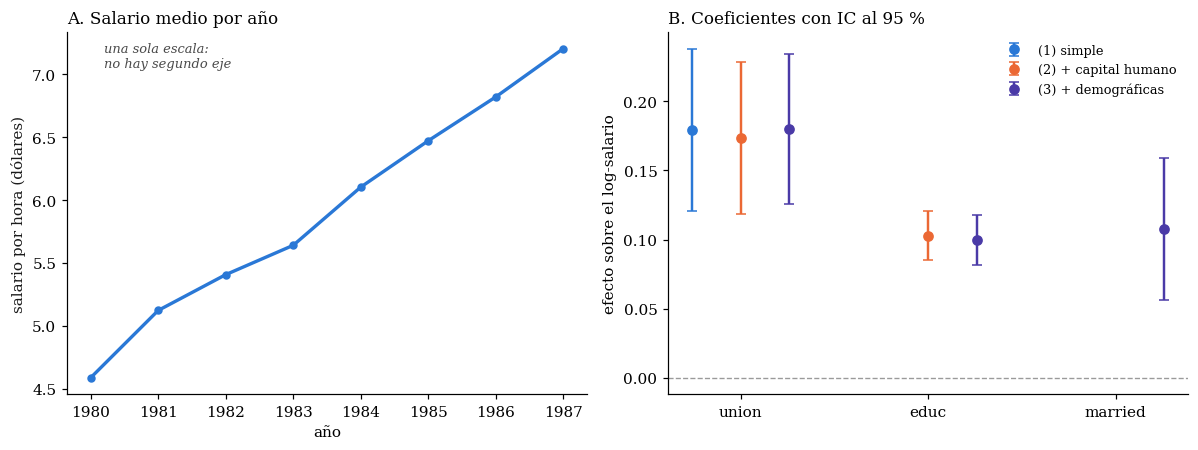

In [9]:
fig, (izq, der) = plt.subplots(1, 2, figsize=(11, 4.2))

# ---- Panel A: evolución de dos series con escalas distintas ----------------
anios = por_anio.index.values
izq.plot(anios, por_anio["salario_medio"], color=AZUL, lw=2.2, marker="o", ms=4.5)
izq.set_xlabel("año")
izq.set_ylabel("salario por hora (dólares)", color=TINTA)
izq.set_title("A. Salario medio por año", loc="left", fontsize=11)
izq.text(1980.2, por_anio["salario_medio"].max() * 0.98,
         "una sola escala:\nno hay segundo eje", fontsize=8.5,
         style="italic", color=TINTA2)

# ---- Panel B: coeficientes con intervalos ---------------------------------
variables = ["union", "educ", "married"]
posiciones = np.arange(len(variables))
ancho_barra = 0.26
colores = [AZUL, NARANJA, VIOLETA]

for i, (nombre, modelo) in enumerate(modelos.items()):
    presentes = [v for v in variables if v in modelo.params.index]
    x = [variables.index(v) + (i - 1) * ancho_barra for v in presentes]
    coefs = [modelo.params[v] for v in presentes]
    errs = [1.96 * modelo.bse[v] for v in presentes]
    der.errorbar(x, coefs, yerr=errs, fmt="o", color=colores[i], ms=6,
                 capsize=3, lw=1.6, label=nombre)

der.axhline(0, color=GRIS, lw=0.9, ls="--")
der.set_xticks(posiciones)
der.set_xticklabels(variables)
der.set_ylabel("efecto sobre el log-salario")
der.set_title("B. Coeficientes con IC al 95 %", loc="left", fontsize=11)
der.legend(frameon=False, fontsize=8.5, loc="upper right")

plt.tight_layout()
plt.show()

### Las tres reglas

**1. Un solo eje vertical por panel.** Nunca dos escalas en la misma gráfica. Con dos ejes
se puede hacer que dos series cualesquiera parezcan moverse juntas o en contra, sólo
eligiendo los rangos: la conclusión la fija quien dibuja, no los datos. Si hay dos medidas
de escala distinta, van dos paneles —como aquí— o se indizan a una base común.

**2. La incertidumbre se muestra.** El panel B lleva intervalos de confianza. Un gráfico de
barras con las alturas de los coeficientes y sin intervalos sugiere una precisión que no
existe; es la forma más común de exagerar un resultado sin decir una sola mentira.

**3. El color identifica, no decora.** Cada especificación conserva su color en toda la
figura. La paleta está validada para daltonismo —cerca del 8 % de los hombres tiene alguna
deficiencia de visión del color— y los marcadores permiten distinguir las series aunque se
imprima en blanco y negro, que es como muchos alumnos las leen.

> **Lo que el panel B muestra y un cuadro no.** El coeficiente de `union` cae al agregar
> controles, pero los intervalos de las tres especificaciones se traslapan ampliamente:
> las diferencias entre ellas no son estadísticamente distinguibles. Esa lectura es
> inmediata en la figura y hay que reconstruirla mentalmente a partir del cuadro.

## 7. Guardar resultados de forma reproducible

Los cuadros y figuras se **generan con código**, nunca se editan a mano. Si hay que
rehacerlos con datos corregidos —y siempre hay que rehacerlos— la edición manual se pierde
y los números del texto dejan de corresponder a los del código.

In [10]:
from pathlib import Path

salida = Path("resultados")
salida.mkdir(exist_ok=True)

cuadro.to_csv(salida / "cuadro_sindicato.csv")
fig.savefig(salida / "figura_sindicato.png", dpi=200, bbox_inches="tight",
            facecolor="white")

print("Guardado en resultados/:")
for archivo in sorted(salida.iterdir()):
    print(f"  {archivo.name}  ({archivo.stat().st_size / 1024:.1f} KB)")
print()
print("Nota: la carpeta resultados/ se regenera al ejecutar el cuaderno,")
print("de modo que no necesita versionarse. Ver el .gitignore del repositorio.")

Guardado en resultados/:
  cuadro_sindicato.csv  (0.3 KB)
  figura_sindicato.png  (116.7 KB)

Nota: la carpeta resultados/ se regenera al ejecutar el cuaderno,
de modo que no necesita versionarse. Ver el .gitignore del repositorio.


---

## Ejercicios

1. **Media aritmética o geométrica.** El cuadro de la sección 5 reporta efectos sobre el
   *log*-salario. Tradúcelos a porcentajes de dos maneras: con $\beta$ y con
   $e^{\beta}-1$. ¿Cuál corresponde a cada concepto de media de la sección 2? Ver el
   CASO 4 de `04_Verificar_resultados`.
2. **Una figura engañosa, a propósito.** Rehaz el panel A con dos ejes verticales, poniendo
   el salario medio y la tasa de sindicalización juntos. Ajusta los rangos para que
   parezcan moverse juntos; luego ajústalos para que parezcan moverse en contra. Con los
   **mismos datos**. Guarda las dos versiones y explica por qué este curso prohíbe el
   doble eje.
3. **Datos sucios.** Introduce deliberadamente 50 faltantes aleatorios en `educ` y repite
   el cuadro de la sección 5. ¿Cambia `N` en las tres columnas por igual? ¿Siguen siendo
   comparables entre sí? (BUG 02.)
4. **Un cuadro por grupo.** Construye el cuadro de la sección 5 por separado para
   trabajadores casados y no casados. ¿Conviene un cuadro doble o una figura de
   coeficientes? Justifica la elección por lo que quieres que el lector compare.
5. **`seaborn`.** Reproduce el panel B con `seaborn` en vez de `matplotlib`. ¿Qué decisiones
   toma la biblioteca por ti —paleta, rejilla, orden de las categorías— y cuáles de ellas
   habrías tomado distinto? Ése es el punto del ejercicio.

---
Parte del curso de **Econometría I**, Facultad de Ciencias, UNAM.
Ver el [README de la carpeta](../README.md) para el calendario de actividades.